<a href="https://colab.research.google.com/github/flaviogyn/pos-ia-aplicada-ifg/blob/main/Torres_de_Hanoi_e_Implementa%C3%A7%C3%A3o_em_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Towers of Hanoi and Python Implementation using Depth First Search (DFS)

INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA - GOIÁS

CAMPUS GOIÂNIA

PÓS-GRADUAÇÃO EM INTELIGÊNCIA ARTIFICIAL APLICADA

DISCIPLINA: BUSCA COM IA

TURMA: 2026

PROFESSOR: Dr. Eduardo Noronha

ALUNO: Flávio Lourenço da Silva

## Regras



1.   Mover apenas um disco de cada vez de uma estaca para outra, sempre do topp da haste
2.   Nunca coloque um disco maior sobre o menor
3.   Transferir toda a pilha de discos para uma nova estaca





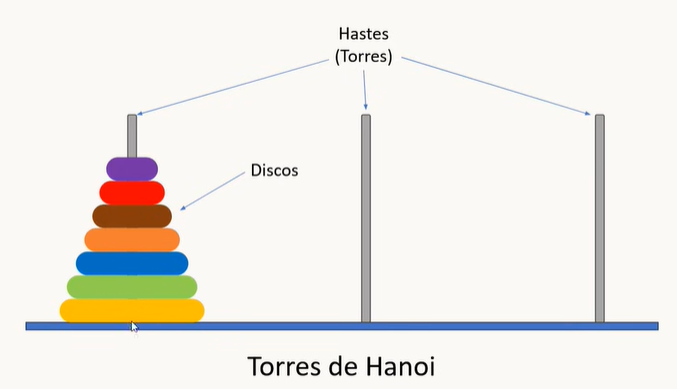

In [5]:
# Using Depth First Search

# Orientação
'''
Base
3  ← maior (embaixo)
2
1  ← menor (em cima)
Topo
'''

qtd_torres = 3

def mostrar_solucao(estado):
    nomes = ["[A] Origem", "[B] Auxiliar", "[C] Destino"]
    print("\n📦 Estado atual:")

    for i, torre in enumerate(estado): # enumerate traz index das informações
        print(f"Torre {nomes[i]}: {torre}")

    print("-" * 30)


def copiar_estado(estado):
    # cópia simples (suficiente para listas de listas)
    return [torre[:] for torre in estado]


def movimentos(estado):
    estados = []

    for origem in range(qtd_torres):
        if not estado[origem]:
            continue

        for destino in range(qtd_torres):
            if origem != destino:
                if not estado[destino] or estado[origem][-1] < estado[destino][-1]:

                    novo = copiar_estado(estado)

                    disco = novo[origem].pop()  # desempilhar > remove do topo
                    novo[destino].append(disco) # empilhar > adiciona no topo

                    estados.append((novo, origem, destino))

    return estados


def busca_hanoi(n):
    # Calcula a quantidade
    qtd_num = range(n, 0, -1)

    inicial = [list(qtd_num), [], []]
    objetivo = [[], [], list(qtd_num)]

    pilha = [(inicial, [])]
    visitados = set()

    while pilha:
        estado, caminho = pilha.pop() # desempilhar > remove do topo

        chave = tuple(tuple(t) for t in estado)
        if chave in visitados:
            continue

        # Já visitados
        visitados.add(chave)

        mostrar_solucao(estado)

        if estado == objetivo:
            print("🏆 Resolvido!")
            return

        for prox, origem, destino in movimentos(estado):
            print(f"➡️ {['A','B','C'][origem]} → {['A','B','C'][destino]}")
            pilha.append((prox, caminho + [estado]))


# Executar
busca_hanoi(7)


📦 Estado atual:
Torre [A] Origem: [3, 2, 1]
Torre [B] Auxiliar: []
Torre [C] Destino: []
------------------------------
➡️ A → B
➡️ A → C

📦 Estado atual:
Torre [A] Origem: [3, 2]
Torre [B] Auxiliar: []
Torre [C] Destino: [1]
------------------------------
➡️ A → B
➡️ C → A
➡️ C → B

📦 Estado atual:
Torre [A] Origem: [3, 2]
Torre [B] Auxiliar: [1]
Torre [C] Destino: []
------------------------------
➡️ A → C
➡️ B → A
➡️ B → C

📦 Estado atual:
Torre [A] Origem: [3]
Torre [B] Auxiliar: [1]
Torre [C] Destino: [2]
------------------------------
➡️ B → A
➡️ B → C
➡️ C → A

📦 Estado atual:
Torre [A] Origem: [3]
Torre [B] Auxiliar: []
Torre [C] Destino: [2, 1]
------------------------------
➡️ A → B
➡️ C → A
➡️ C → B

📦 Estado atual:
Torre [A] Origem: [3, 1]
Torre [B] Auxiliar: []
Torre [C] Destino: [2]
------------------------------
➡️ A → B
➡️ A → C
➡️ C → B

📦 Estado atual:
Torre [A] Origem: [3, 1]
Torre [B] Auxiliar: [2]
Torre [C] Destino: []
------------------------------
➡️ A → B
➡️ A 

In [ ]:
# Using Breadth First Search

# Orientação
'''
Base
3  ← maior (embaixo)
2
1  ← menor (em cima)
Topo
'''

# O deque é recomendado quando você precisa de uma fila (FIFO - First In, First Out) ou pilha (LIFO - Last In, First Out) de alto desempenho
from collections import deque

def copiar_estado(estado):
    return [torre[:] for torre in estado]

def vizinhos(estado):
    estados = []

    for origem in range(3):
        if not estado[origem]:
            # Não achou correspondente
            continue

        for destino in range(3):
            if origem != destino:
                if not estado[destino] or estado[origem][-1] < estado[destino][-1]:

                    novo = copiar_estado(estado)

                    disco = novo[origem].pop()   # desempilhar > remove do topo
                    novo[destino].append(disco)  # empilhar > adiciona no topo

                    estados.append((novo, origem, destino))

    return estados

def busca_hanoi(n):
    # Calcula a quantidade
    num = range(n, 0, -1)

    inicio = [list(num), [], []]
    objetivo = [[], [], list(num)]

    X = set()                       # visitados
    F = deque([[inicio]])           # fila com caminhos

    while True:
        if not F:
            return "FALHA"          # caso tenha falha

        caminho = F.popleft()       # retira a esquerda
        estado = caminho[-1]        # pega o caminho

        chave = tuple(tuple(t) for t in estado)

        if estado == objetivo:
            return caminho

        if chave not in X:
            X.add(chave)

            for prox, origem, destino in vizinhos(estado):
                novo_caminho = caminho + [prox]
                F.append(novo_caminho)


def mostrar_solucao(caminho):
    nomes = ["Origem", "Auxiliar", "Destino"]

    for i, estado in enumerate(caminho): # enumerate traz index das informações
        print(f"\nPasso {i}:")
        for j in range(3):
            print(f"Torre {nomes[j]}: {estado[j]}")
        print("-" * 25)


# Execução
solucao = busca_hanoi(7)
mostrar_solucao(solucao)


Passo 0:
Torre Origem: [7, 6, 5, 4, 3, 2, 1]
Torre Auxiliar: []
Torre Destino: []
-------------------------

Passo 1:
Torre Origem: [7, 6, 5, 4, 3, 2]
Torre Auxiliar: []
Torre Destino: [1]
-------------------------

Passo 2:
Torre Origem: [7, 6, 5, 4, 3]
Torre Auxiliar: [2]
Torre Destino: [1]
-------------------------

Passo 3:
Torre Origem: [7, 6, 5, 4, 3]
Torre Auxiliar: [2, 1]
Torre Destino: []
-------------------------

Passo 4:
Torre Origem: [7, 6, 5, 4]
Torre Auxiliar: [2, 1]
Torre Destino: [3]
-------------------------

Passo 5:
Torre Origem: [7, 6, 5, 4, 1]
Torre Auxiliar: [2]
Torre Destino: [3]
-------------------------

Passo 6:
Torre Origem: [7, 6, 5, 4, 1]
Torre Auxiliar: []
Torre Destino: [3, 2]
-------------------------

Passo 7:
Torre Origem: [7, 6, 5, 4]
Torre Auxiliar: []
Torre Destino: [3, 2, 1]
-------------------------

Passo 8:
Torre Origem: [7, 6, 5]
Torre Auxiliar: [4]
Torre Destino: [3, 2, 1]
-------------------------

Passo 9:
Torre Origem: [7, 6, 5]
Torre Aux